(5804826, 12)
       timestamp         x         y         z activity_code sensor_type  \
0  2318482693000  0.890643 -9.576807 -0.019154           BSC         acc   
1  2318492108000  0.919373 -9.595961 -0.057461           BSC         acc   
2  2318503365000  0.871489 -9.595961 -0.057461           BSC         acc   
3  2318512831000  0.852336 -9.643845 -0.038307           BSC         acc   
4  2318523222000  0.871489 -9.634268 -0.057461           BSC         acc   

   subject_id  trial_number category  azimuth  pitch  roll  
0           1             1     FALL      NaN    NaN   NaN  
1           1             1     FALL      NaN    NaN   NaN  
2           1             1     FALL      NaN    NaN   NaN  
3           1             1     FALL      NaN    NaN   NaN  
4           1             1     FALL      NaN    NaN   NaN  
                  count          mean           std           min  \
timestamp     5804826.0  3.326496e+12  2.942612e+12  7.597068e+10   
x             3434354.0 -

C:\Users\aishw\AppData\Local\Temp\ipykernel_20912\1087571484.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='category', palette='coolwarm')


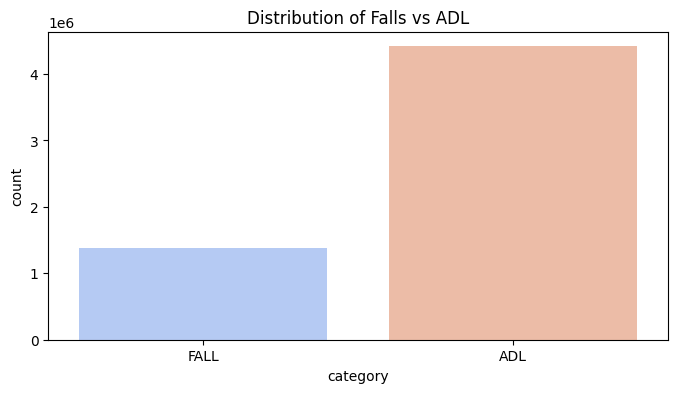

C:\Users\aishw\AppData\Local\Temp\ipykernel_20912\1087571484.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sensor_type', palette='mako')


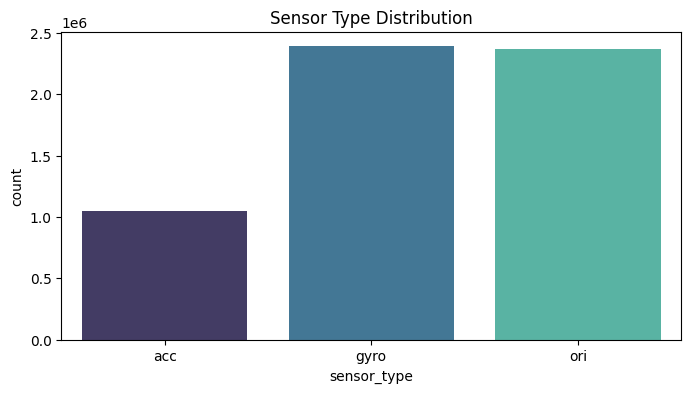

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("MobiFall_All.csv")

print(df.shape)
print(df.head())
print(df.describe().T)

if 'category' in df.columns:
    print(df['category'].value_counts())

if 'subject_id' in df.columns:
    print("Unique subjects:", df['subject_id'].nunique())

plt.figure(figsize=(8,4))
if 'category' in df.columns:
    sns.countplot(data=df, x='category', palette='coolwarm')
    plt.title('Distribution of Falls vs ADL')
    plt.show()

plt.figure(figsize=(8,4))
if 'sensor_type' in df.columns:
    sns.countplot(data=df, x='sensor_type', palette='mako')
    plt.title('Sensor Type Distribution')
    plt.show()



C:\Users\aishw\AppData\Local\Temp\ipykernel_20912\2637814860.py:34: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Python310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


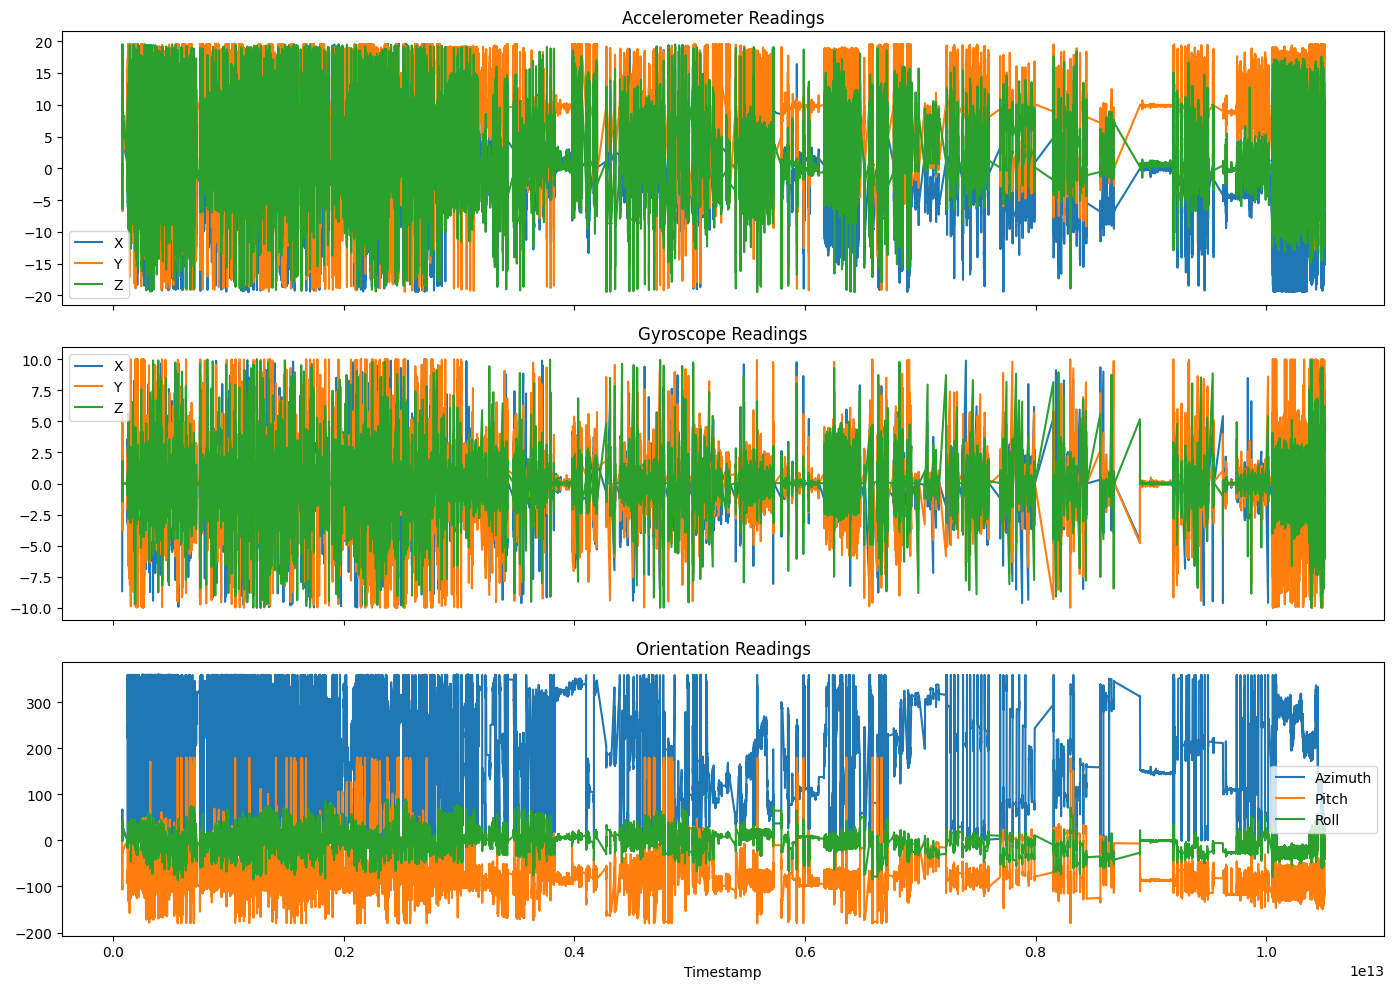

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("MobiFall_All.csv")

df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
df = df.sort_values('timestamp')

acc_df = df[df['sensor_type'] == 'acc']
gyro_df = df[df['sensor_type'] == 'gyro']
orient_df = df[df['sensor_type'] == 'ori']

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(acc_df['timestamp'], acc_df['x'], label='X')
axes[0].plot(acc_df['timestamp'], acc_df['y'], label='Y')
axes[0].plot(acc_df['timestamp'], acc_df['z'], label='Z')
axes[0].set_title('Accelerometer Readings')
axes[0].legend()

axes[1].plot(gyro_df['timestamp'], gyro_df['x'], label='X')
axes[1].plot(gyro_df['timestamp'], gyro_df['y'], label='Y')
axes[1].plot(gyro_df['timestamp'], gyro_df['z'], label='Z')
axes[1].set_title('Gyroscope Readings')
axes[1].legend()

axes[2].plot(orient_df['timestamp'], orient_df['azimuth'], label='Azimuth')
axes[2].plot(orient_df['timestamp'], orient_df['pitch'], label='Pitch')
axes[2].plot(orient_df['timestamp'], orient_df['roll'], label='Roll')
axes[2].set_title('Orientation Readings')
axes[2].legend()

plt.xlabel('Timestamp')
plt.tight_layout()
plt.show()
